In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import scipy
import glob


In [3]:
import requests

lat, lon = 62.58, -114.43

url = (
    f"https://modis.ornl.gov/rst/api/v1/MCD12Q1/subset"
    f"?latitude={lat}&longitude={lon}&startDate=A2010001&endDate=A2010001&kmAboveBelow=0&kmLeftRight=0"
)

response = requests.get(url, headers={"Accept": "application/json"})
data = response.json()

for subset in data["subset"]:
    if subset["band"] == "LC_Type1":
        print("IGBP class:", subset["data"][0])

ConnectTimeout: HTTPSConnectionPool(host='modis.ornl.gov', port=443): Max retries exceeded with url: /rst/api/v1/MCD12Q1/subset?latitude=62.58&longitude=-114.43&startDate=A2010001&endDate=A2010001&kmAboveBelow=0&kmLeftRight=0 (Caused by ConnectTimeoutError(<HTTPSConnection(host='modis.ornl.gov', port=443) at 0x28225e51d30>, 'Connection to modis.ornl.gov timed out. (connect timeout=None)'))

## Graphing CTSM data 

In [3]:
# Open one file
ds = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")
ds



/tmp/ipykernel_62173/2269508667.py:2: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")


<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 7300, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 58kB 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 29kB ...
    mcsec                          (time) int32 29kB ...
    mdcur                          (time) int32 29kB ...
    mscur                          (time) int32 29kB ...
    nstep                          (time) int32 29kB ...
    time_bounds                    (time, hist_interval) object 117kB ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 584kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 263kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 438kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 117kB ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

In [12]:
jan_ds = ds.isel(time=slice(-31, -1))
jan_ds

<xarray.Dataset> Size: 61kB
Dimensions:                        (time: 30, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 240B 2014-12-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 120B ...
    mcsec                          (time) int32 120B ...
    mdcur                          (time) int32 120B ...
    mscur                          (time) int32 120B ...
    nstep                          (time) int32 120B ...
    time_bounds                    (time, hist_interval) object 480B ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 2kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 1kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 2kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 480B ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 480B ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 480B ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

## Script for Sanity Checking

This funtion checks that the first and last month of the merged data is identical to the first and last month done manually. This maybe only needs to be run when there is an error or we want to be really safe, but the function is good to have.

In [7]:
def monthly_sanity(folder, merged):

    full_data = xr.open_dataset(f"{merged}.nc", engine="netcdf4")
    jan_data = full_data.isel(time=slice(0, 31))

    # Open all files at once
    files = sorted(glob.glob(f"{folder}/*.nc"))
    ds = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", decode_timedelta=False, data_vars="minimal")

    var_man = ds["TSOI_10CM"]
    var_mer = jan_data["TSOI_10CM"]

    # Plot
    var_man.plot()
    var_mer.plot()
    plt.show()


## Sanity check for merged data (1 month)

In [4]:
ds_test = xr.open_dataset("merged_test.nc", engine="netcdf4")
ds_test

/tmp/ipykernel_26886/2828503391.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_test = xr.open_dataset("merged_test.nc", engine="netcdf4")


<xarray.Dataset> Size: 63kB
Dimensions:                        (time: 31, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 248B 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 124B ...
    mcsec                          (time) int32 124B ...
    mdcur                          (time) int32 124B ...
    mscur                          (time) int32 124B ...
    nstep                          (time) int32 124B ...
    time_bounds                    (time, hist_interval) object 496B ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 2kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 1kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 2kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 496B ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 496B ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 496B ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:08:09 2026: ncrcat te...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

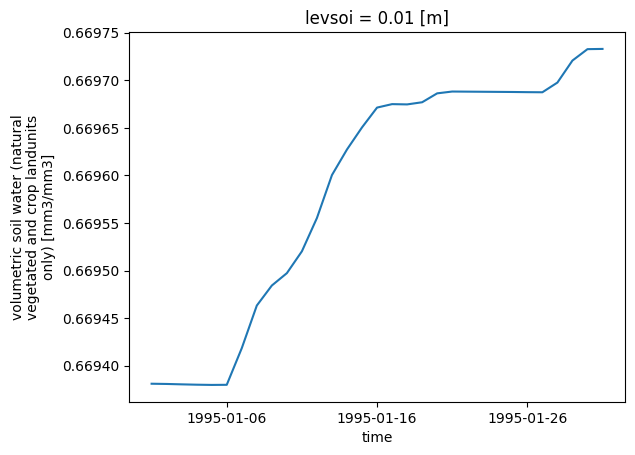

In [5]:
# Select surface soil layer only
var_test = ds_test["H2OSOI"].sel(levsoi=0.01, method="nearest")

# Plot
var_test.plot()
plt.show()

In [6]:
var.equals(var_test)

True

## Sanity check for merged data (20 years)

In [8]:
ds_final = xr.open_dataset("merged.nc", engine="netcdf4")
ds_final

/tmp/ipykernel_26886/1784542849.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_final = xr.open_dataset("merged.nc", engine="netcdf4")


<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 7300, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 58kB 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 29kB ...
    mcsec                          (time) int32 29kB ...
    mdcur                          (time) int32 29kB ...
    mscur                          (time) int32 29kB ...
    nstep                          (time) int32 29kB ...
    time_bounds                    (time, hist_interval) object 117kB ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 584kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 263kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 438kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 117kB ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

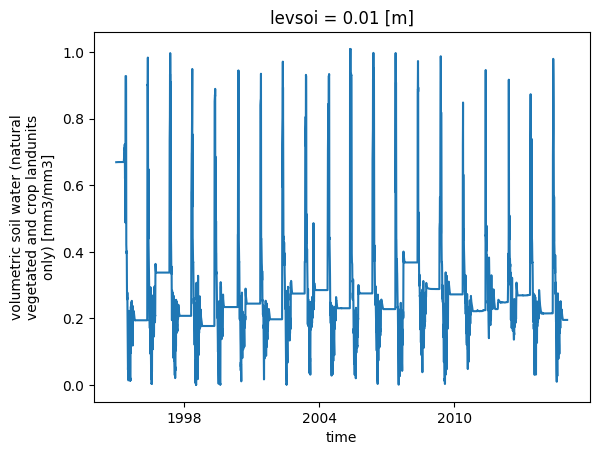

In [ ]:
# Select surface soil layer only
var_final = ds_final["TSOI"].sel(levsoi=0.01, method="nearest")

# Plot
var_final.plot()
plt.show()